In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [6]:
import csv

FILE_PATH = "../dataset/dataset_capacity.csv"

# Membuat range waktu dari 2019-01-01 00:00 hingga 2019-12-31 23:00 dengan frekuensi per jam
time_range = pd.date_range(start='2019-01-01 00:00', end='2019-12-31 23:00', freq='h')

# Membaca data dari file
data = []
with open(FILE_PATH, 'r', encoding='utf-8') as file:
    reader = csv.reader(file, delimiter=',')
    next(reader)  # Skip header row

    for row in reader:
        load = row[0]
        sg = row[1]
        data.append((float(load), float(sg)))

# Konversi list menjadi DataFrame
df = pd.DataFrame(data, columns=['Load', 'SG'])

# Memastikan jumlah baris dalam time_range dan df sama
if len(time_range) == len(df):
    df['Time'] = time_range
else:
    print("Warning: The number of time points does not match the number of data rows.")

# Set time as the index
df.set_index('Time', inplace=True)


In [7]:
df.head()

,Load,SG
Time,,
2019-01-01 00:00:00,223.449142,0.0
2019-01-01 01:00:00,203.311678,0.0
2019-01-01 02:00:00,180.198849,0.0
2019-01-01 03:00:00,146.232528,0.0
2019-01-01 04:00:00,168.747932,0.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8760 entries, 2019-01-01 00:00:00 to 2019-12-31 23:00:00
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Load    8760 non-null   float64
 1   SG      8760 non-null   float64
dtypes: float64(2)
memory usage: 205.3 KB


In [9]:
print(df.shape)

(8760, 2)


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8760 entries, 2019-01-01 00:00:00 to 2019-12-31 23:00:00
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Load    8760 non-null   float64
 1   SG      8760 non-null   float64
dtypes: float64(2)
memory usage: 205.3 KB


/var/folders/97/8bx4_dmx3038pm1qrblmtrl80000gn/T/ipykernel_25674/1840429969.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = df.resample('M').mean()


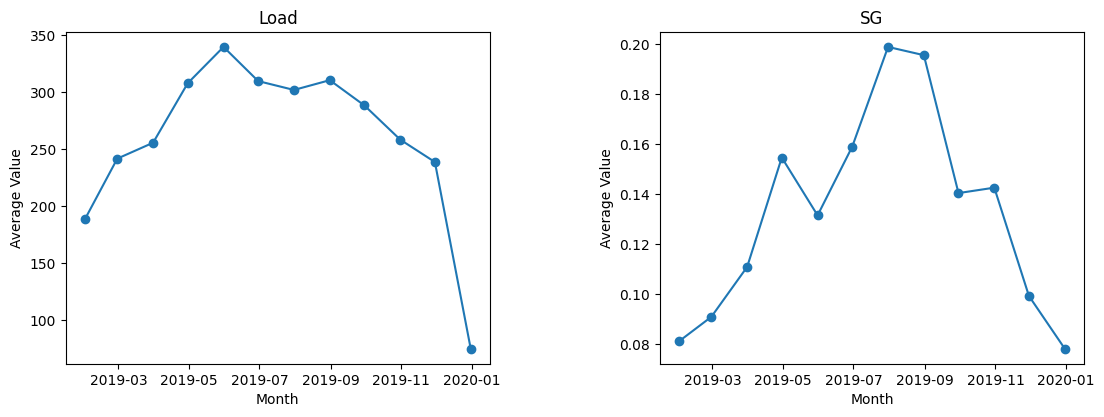

In [11]:
# Pastikan index sudah dalam format datetime
df.index = pd.to_datetime(df.index)

# Resampling data per bulan dengan rata-rata
monthly_data = df.resample('M').mean()

# Setup plot
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))  # Mengubah ukuran dan jumlah subplot
fig.tight_layout(pad=5.0)

# Nama kolom untuk plotting
columns = ['Load', 'SG']

# Loop untuk plotting setiap fitur
for i, column in enumerate(columns):
    ax = axes[i]  # Mengatur subplot berdasarkan posisi
    ax.plot(monthly_data.index, monthly_data[column], marker='o', linestyle='-')
    ax.set_title(column)
    ax.set_xlabel('Month')
    ax.set_ylabel('Average Value')

# Ajust space between plots
plt.subplots_adjust(hspace=0.4, wspace=0.4)

# Tampilkan plot
plt.show()